In [1]:
import torch
import pandas as pd
from pathlib import Path
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import numpy as np
import ast

/Users/anshulraj/Data/Workspace/podcast-emotion-dynamics/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- CONFIGURATION ---
VIDEO_ID = 't58X0md283Y'  # replace with a real ID
TRANSCRIPT_PATH = Path(f"data/raw/transcripts/{VIDEO_ID}.csv")
OUTPUT_PATH = Path(f"data/processed/emotions/{VIDEO_ID}_emotions.csv")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

In [3]:
# --- LOAD TRANSCRIPT ---
df = pd.read_csv(TRANSCRIPT_PATH)

In [67]:
# --- ADAPTIVE SEGMENTATION ---
def segment_transcript(df, max_duration=45.0, min_duration=15.0, min_words=8):
    segments = []
    current_text = ""
    segment_start = df.iloc[0]["start"]
    segment_end = df.iloc[0]["start"]
    current_duration = 0

    for i, row in df.iterrows():
        line = str(row["clean_text"]).strip()
        if not line:
            continue
        
        segment_end = row["start"] + row["duration"]
        current_duration = segment_end - segment_start
        current_text += " " + line

        # Should we finalize this segment?
        should_end = (
            line.endswith(('.', '!', '?')) and
            (current_duration >= min_duration) and
            (len(current_text.split()) >= min_words)
        )

        if should_end or current_duration >= max_duration:
            segments.append({
                "start": segment_start,
                "end": segment_end,
                "text": current_text.strip()
            })
            # reset
            current_text = ""
            if i + 1 < len(df):
                segment_start = df.iloc[i + 1]["start"]

    # Add last leftover
    if current_text.strip():
        segments.append({
            "start": segment_start,
            "end": segment_end,
            "text": current_text.strip()
        })

    return pd.DataFrame(segments)

segmented_df = segment_transcript(df)

In [68]:
segmented_df

,start,end,text
0,0.000,46.000,nan welcome to best practices and experiences ...
1,43.920,88.960,create connections between different countries...
2,86.720,132.080,more than just a tool for communication. its a...
3,129.119,150.720,"learning experiences for children. so, lets ge..."
4,148.160,165.720,with over two decades of experience in pedagog...
5,162.959,208.560,"today, katrina will shed light on transdiscipl..."
6,206.040,252.000,transdisciplinary learning looks like in both ...
7,249.760,295.479,through language and and questions or academic...
8,292.639,338.320,um different vocabulary or sentence starters. ...
9,335.280,382.400,are you also using music uh as a practical thi...


In [69]:
# --- LOAD MODEL ---
model_name = "joeddav/distilbert-base-uncased-go-emotions-student"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name)
model.eval()

# --- EMOTION LABELS ---
id2label = model.config.id2label
threshold = 0.4

In [70]:
# --- EMOTION DETECTION ---
def predict_emotions(texts):
    results = []
    for text in texts:
        inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
        with torch.no_grad():
            logits = model(**inputs).logits
            probs = torch.sigmoid(logits)[0].cpu().numpy()
        labels = [id2label[i] for i, p in enumerate(probs) if p >= threshold]
        results.append((labels, probs.tolist()))
    return results

predictions = predict_emotions(segmented_df["text"])

# --- ADD TO OUTPUT ---
segmented_df["emotions"] = [p[0] for p in predictions]
segmented_df["scores"] = [p[1] for p in predictions]

In [71]:
segmented_df

,start,end,text,emotions,scores
0,0.000,46.000,nan welcome to best practices and experiences ...,"[admiration, approval, caring, curiosity, desi...","[0.6072872281074524, 0.2536270022392273, 0.177..."
1,43.920,88.960,create connections between different countries...,"[admiration, approval, caring, curiosity, desi...","[0.4513295590877533, 0.34680265188217163, 0.19..."
2,86.720,132.080,more than just a tool for communication. its a...,"[admiration, approval, caring, curiosity, desi...","[0.5018633008003235, 0.210430309176445, 0.2031..."
3,129.119,150.720,"learning experiences for children. so, lets ge...","[admiration, amusement, approval, caring, curi...","[0.5902700424194336, 0.4422118663787842, 0.115..."
4,148.160,165.720,with over two decades of experience in pedagog...,"[admiration, approval, caring, curiosity, desi...","[0.5058263540267944, 0.1623634248971939, 0.281..."
5,162.959,208.560,"today, katrina will shed light on transdiscipl...","[approval, caring, curiosity, desire, gratitud...","[0.3909946084022522, 0.17697417736053467, 0.25..."
6,206.040,252.000,transdisciplinary learning looks like in both ...,"[admiration, approval, caring, confusion, curi...","[0.4242557883262634, 0.2412223070859909, 0.259..."
7,249.760,295.479,through language and and questions or academic...,"[anger, annoyance, approval, caring, confusion...","[0.1605149805545807, 0.14371357858181, 0.45810..."
8,292.639,338.320,um different vocabulary or sentence starters. ...,"[admiration, approval, caring, confusion, curi...","[0.4324931502342224, 0.21268759667873383, 0.21..."
9,335.280,382.400,are you also using music uh as a practical thi...,"[annoyance, approval, caring, confusion, curio...","[0.35628095269203186, 0.28487318754196167, 0.2..."


In [72]:
# --- SAVE ---
segmented_df.to_csv(OUTPUT_PATH, index=False)
print(f"Saved emotion results to: {OUTPUT_PATH}")

Saved emotion results to: data/processed/emotions/t58X0md283Y_emotions.csv


In [73]:
# Emotion polarity mapping (based on GoEmotions paper categories)
positive_emotions = {
    'admiration', 'amusement', 'approval', 'caring', 'desire', 'excitement',
    'gratitude', 'joy', 'love', 'optimism', 'pride', 'relief'
}
negative_emotions = {
    'anger', 'annoyance', 'disappointment', 'disapproval', 'disgust', 'embarrassment',
    'fear', 'grief', 'nervousness', 'remorse', 'sadness'
}
neutral_emotions = set(id2label.values()) - positive_emotions - negative_emotions

def get_color(emotion):
    if emotion in positive_emotions:
        return "green"
    elif emotion in negative_emotions:
        return "red"
    else:
        return "gray"

In [74]:
import matplotlib.pyplot as plt
import numpy as np

# Create a time column (segment midpoint)
segmented_df["time"] = (segmented_df["start"] + segmented_df["end"]) / 2

# Extract emotion scores into a DataFrame
emotion_scores = pd.DataFrame(segmented_df["scores"].tolist(), columns=[id2label[i] for i in range(len(id2label))])
emotion_scores["time"] = segmented_df["time"]

# Optional: Filter to top 5 most common predicted emotions
top_emotions = pd.Series(np.concatenate(segmented_df["emotions"].values)).value_counts().head(5).index.tolist()
emotion_scores_top = emotion_scores[["time"] + top_emotions]

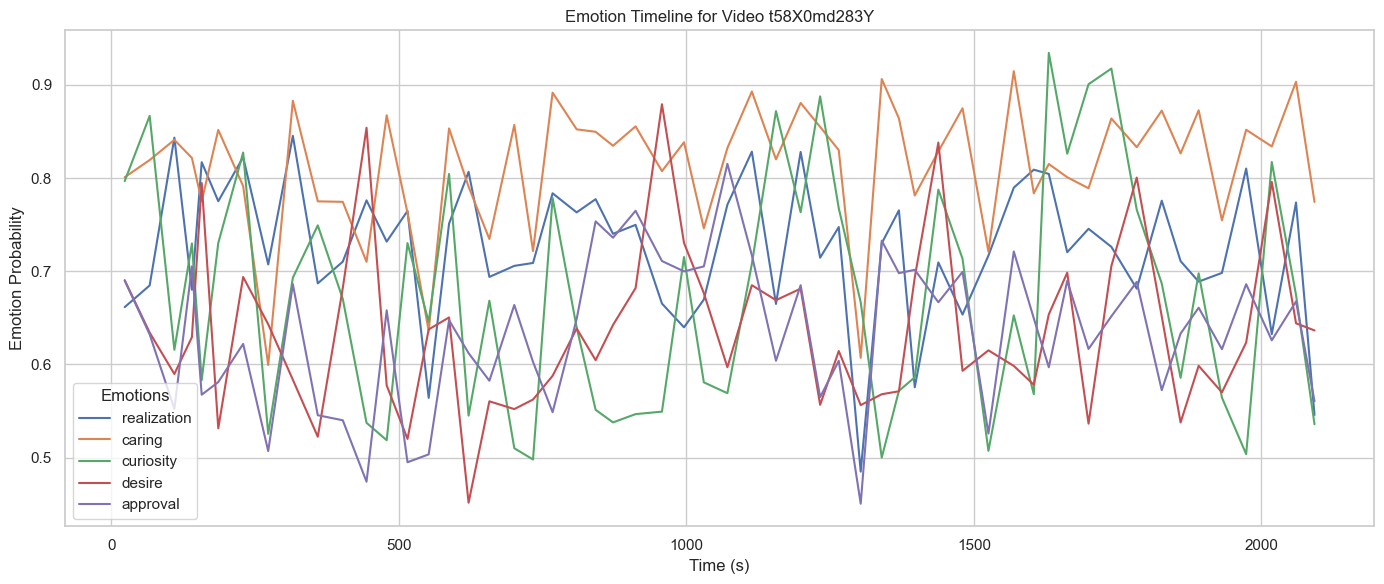

In [75]:
plt.figure(figsize=(14, 6))
for emotion in top_emotions:
    plt.plot(emotion_scores_top["time"], emotion_scores_top[emotion], label=emotion)

plt.xlabel("Time (s)")
plt.ylabel("Emotion Probability")
plt.title(f"Emotion Timeline for Video {VIDEO_ID}")
plt.legend(title="Emotions")
plt.tight_layout()
plt.grid(True)
plt.show()

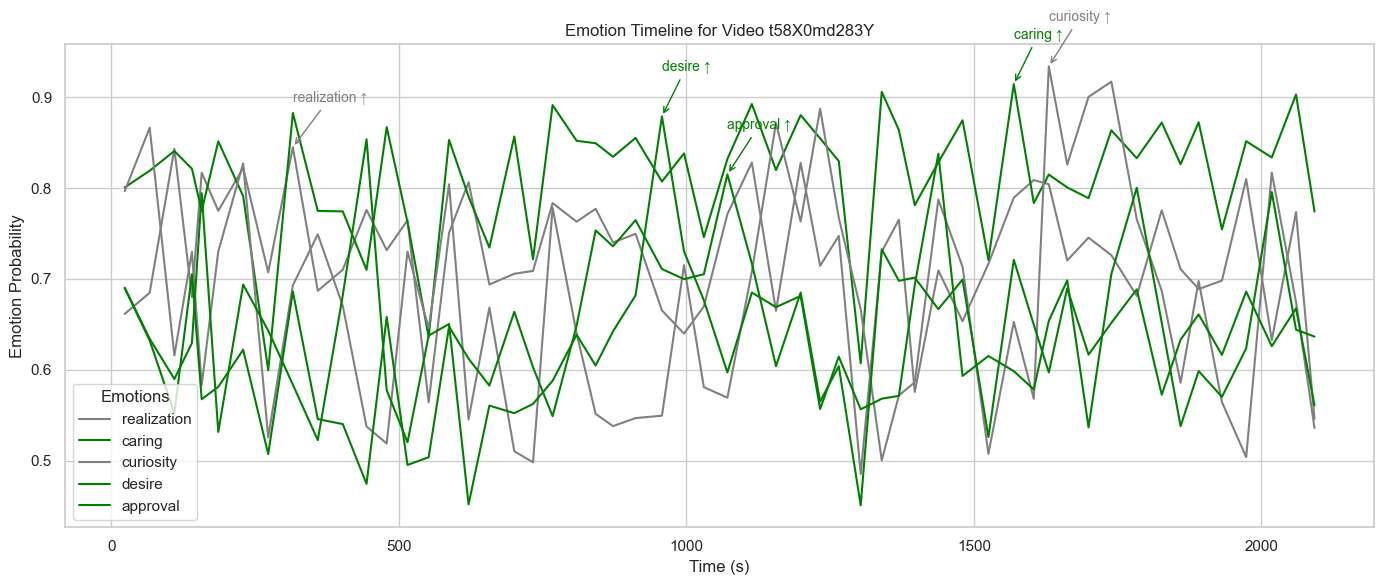

In [76]:
plt.figure(figsize=(14, 6))
for emotion in top_emotions:
    color = get_color(emotion)
    plt.plot(emotion_scores_top["time"], emotion_scores_top[emotion], label=emotion, color=color)

    # Annotate peak
    peak_idx = emotion_scores_top[emotion].idxmax()
    peak_time = emotion_scores_top["time"].iloc[peak_idx]
    peak_val = emotion_scores_top[emotion].iloc[peak_idx]
    if peak_val > 0.1:  # only annotate meaningful peaks
        plt.annotate(f'{emotion} ↑', xy=(peak_time, peak_val),
                     xytext=(peak_time, peak_val + 0.05),
                     arrowprops=dict(arrowstyle='->', color=color),
                     fontsize=10, color=color)

plt.xlabel("Time (s)")
plt.ylabel("Emotion Probability")
plt.title(f"Emotion Timeline for Video {VIDEO_ID}")
plt.legend(title="Emotions")
plt.grid(True)
plt.tight_layout()
plt.show()

In [44]:
import seaborn as sns
from itertools import product

In [58]:
TRANSCRIPT_DIR = Path("data/raw/transcripts")
EXAMPLE_VIDEO_IDS = [
    "-XWfePa3Tck",  # replace with real IDs
    "2AkQwZ_3pqA",
    "5tgiGq7I360",
    "8ehzQreuvVU",
    "BX6AnYZhuNo",
    "HZlsBavSslI",
    "JtzzTl2n8sk",
    "t58X0md283Y",
    "thZ2Fn3PPSU",
    "thZ2Fn3PPSU",
    "YlYxDTQNZt0",
]

# --- PARAMETER GRID ---
param_grid = {
    'max_duration': [30, 45, 60, 75, 90],
    'min_duration': [3, 5, 10, 15],
    'min_words': [3, 5, 8, 10]
}

In [59]:
# --- SCORING FUNCTION ---
def evaluate_segments(segments):
    if len(segments) == 0:
        return {"score": -np.inf, "n_segments": 0, "avg_duration": 0, "avg_words": 0, "punctuation_rate": 0}

    avg_duration = (segments["end"] - segments["start"]).mean()
    avg_words = segments["text"].apply(lambda x: len(x.split())).mean()
    punctuation_rate = segments["text"].apply(lambda x: x[-1] in ".!?" if x else False).mean()
    n_segments = len(segments)

    score = (
        -abs(avg_duration - 45) +         # ideal ~45 sec
        0.5 * punctuation_rate +
        0.1 * avg_words -
        0.01 * n_segments
    )
    return {
        "score": score,
        "n_segments": n_segments,
        "avg_duration": avg_duration,
        "avg_words": avg_words,
        "punctuation_rate": punctuation_rate
    }

In [60]:
# --- RUN GRID SEARCH ---
results = []

for video_id in EXAMPLE_VIDEO_IDS:
    transcript_file = TRANSCRIPT_DIR / f"{video_id}.csv"
    if not transcript_file.exists():
        continue

    df = pd.read_csv(transcript_file)

    for max_d, min_d, min_w in product(param_grid['max_duration'], param_grid['min_duration'], param_grid['min_words']):
        segments = segment_transcript(df, max_d, min_d, min_w)
        metrics = evaluate_segments(segments)
        results.append({
            "video_id": video_id,
            "max_duration": max_d,
            "min_duration": min_d,
            "min_words": min_w,
            **metrics
        })

In [61]:
# --- ANALYZE RESULTS ---
results_df = pd.DataFrame(results)
print("\nTop configurations by score:")
print(results_df.sort_values(by="score", ascending=False).head(10))



Top configurations by score:
        video_id  max_duration  min_duration  min_words      score  \
106  2AkQwZ_3pqA            45            10          8  12.006803   
105  2AkQwZ_3pqA            45            10          5  12.006803   
103  2AkQwZ_3pqA            45             5         10  12.006803   
102  2AkQwZ_3pqA            45             5          8  12.006803   
104  2AkQwZ_3pqA            45            10          3  12.006803   
111  2AkQwZ_3pqA            45            15         10  12.006803   
101  2AkQwZ_3pqA            45             5          5  12.006803   
100  2AkQwZ_3pqA            45             5          3  12.006803   
99   2AkQwZ_3pqA            45             3         10  12.006803   
98   2AkQwZ_3pqA            45             3          8  12.006803   

     n_segments  avg_duration   avg_words  punctuation_rate  
106          61     45.968443  135.770492          0.016393  
105          61     45.968443  135.770492          0.016393  
103          

In [62]:
print("\nTop 2 configurations per video:")
top_per_video = results_df.sort_values(by="score", ascending=False).groupby("video_id").head(2)
print(top_per_video)


Top 2 configurations per video:
        video_id  max_duration  min_duration  min_words      score  \
106  2AkQwZ_3pqA            45            10          8  12.006803   
105  2AkQwZ_3pqA            45            10          5  12.006803   
398  BX6AnYZhuNo            90            15          8  10.856691   
399  BX6AnYZhuNo            90            15         10  10.856691   
260  8ehzQreuvVU            45             5          3  10.735244   
261  8ehzQreuvVU            45             5          5  10.735244   
848  YlYxDTQNZt0            75             3          3  10.102204   
182  5tgiGq7I360            45             5          8   9.919389   
176  5tgiGq7I360            45             3          3   9.919389   
843  YlYxDTQNZt0            60            10         10   8.962725   
511  JtzzTl2n8sk            45            15         10   8.719940   
496  JtzzTl2n8sk            45             3          3   8.719940   
30   -XWfePa3Tck            45            15          8  

In [66]:
print(top_per_video['max_duration'].value_counts())
print(top_per_video['min_duration'].value_counts())
print(top_per_video['min_words'].value_counts())

max_duration
45    14
90     4
75     1
60     1
Name: count, dtype: int64
min_duration
15    7
3     6
5     4
10    3
Name: count, dtype: int64
min_words
8     6
10    6
3     5
5     3
Name: count, dtype: int64


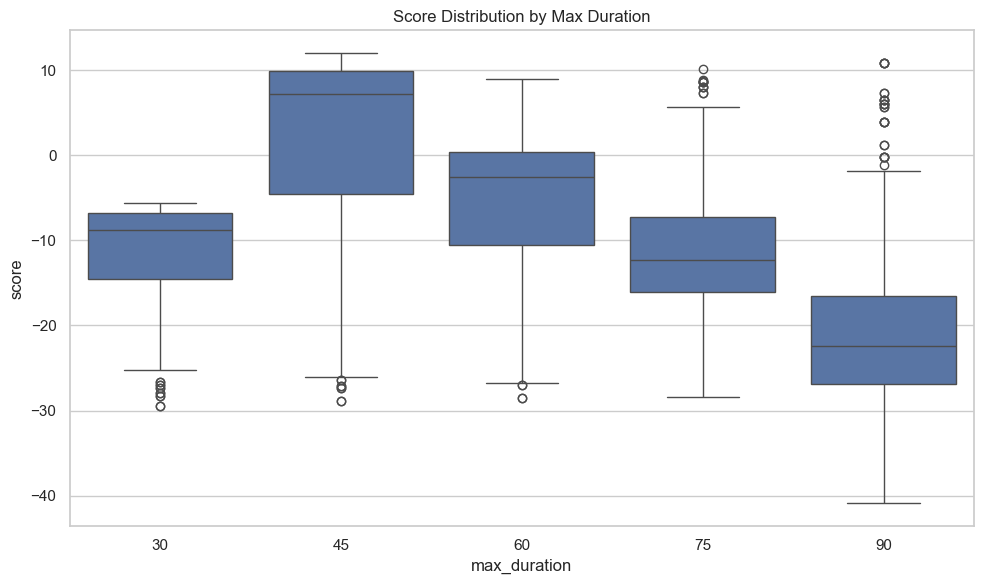

In [63]:
# --- VISUALIZATION ---
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.boxplot(data=results_df, x="max_duration", y="score")
plt.title("Score Distribution by Max Duration")
plt.tight_layout()
plt.show()

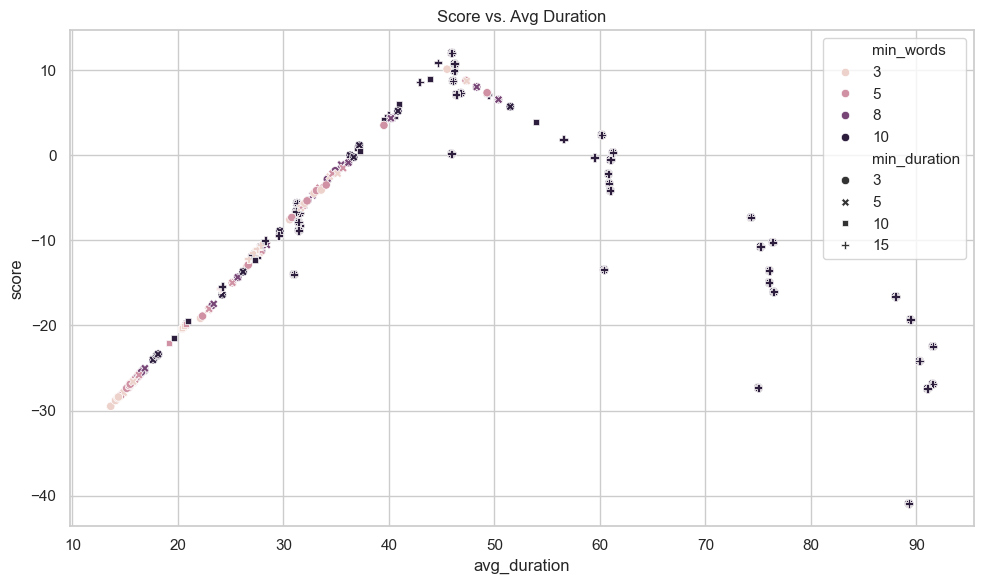

In [64]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=results_df, x="avg_duration", y="score", hue="min_words", style="min_duration")
plt.title("Score vs. Avg Duration")
plt.tight_layout()
plt.show()